In [6]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# read the pickle file 
file_path = "../tracker_stubs/ball_detection.pkl"
with open(file_path, "rb") as f:
    ball_detection = pickle.load(f)


In [7]:
ball_positions = [x.get(1, []) for x in ball_detection]
# convert lists into pandas df 
df_ball_position = pd.DataFrame(ball_positions, columns=["x1", "y1", "x2", "y2"])

# interpolate missing values
df_ball_position = df_ball_position.interpolate()
df_ball_position = df_ball_position.bfill() 

In [ ]:
df_ball_position['mid_y'] = df_ball_position['y1'] + df_ball_position['y2'] / 2
df_ball_position['mid_y_rolling_mean'] = df_ball_position['mid_y'].rolling(window=5, min_periods=1, center=False).mean()


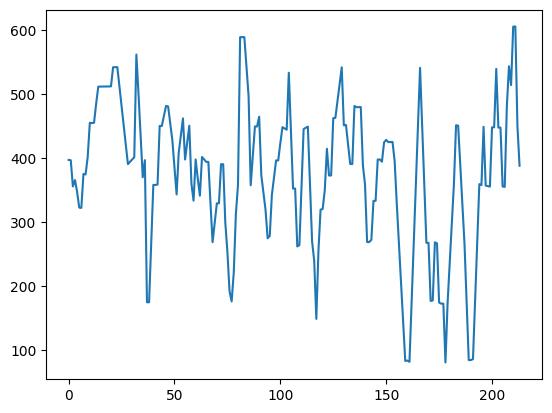

In [11]:
# plot mid_y_rolling_mean 
plt.plot(df_ball_position['mid_y_rolling_mean'])

In [9]:
df_ball_position

,x1,y1,x2,y2
0,1892.295776,221.680115,1919.351074,350.571838
1,1891.966919,221.379364,1919.349976,349.364960
2,68.043938,159.012039,115.890930,229.770401
3,1891.947510,221.107819,1919.356201,348.551605
4,67.776489,158.679810,115.868149,230.001556
...,...,...,...,...
209,1892.514771,218.372833,1919.353638,343.944733
210,28.227573,324.667114,90.241013,427.226166
211,29.480656,324.935638,90.332214,427.125000
212,1892.394287,218.851822,1919.350342,343.446442


In [12]:
df_ball_position['delta_y'] = df_ball_position['mid_y_rolling_mean'].diff()

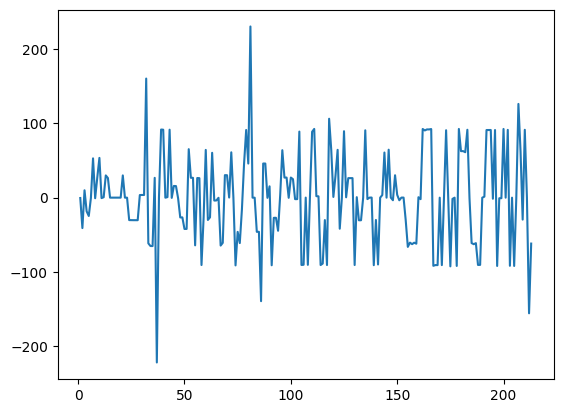

In [13]:
# plot mid_y_rolling_mean 
plt.plot(df_ball_position['delta_y'])

In [14]:
df_ball_position['ball_hit'] = 0

In [ ]:
minimum_change_frames_for_hit = 25
for i in range(1, len(df_ball_position) - int(minimum_change_frames_for_hit*1.2)):
    negative_position_change = df_ball_position['delta_y'].iloc[i] > 0 and df_ball_position['delta_y'].iloc[i+1] < 0
    positive_position_change = df_ball_position['delta_y'].iloc[i] < 0 and df_ball_position['delta_y'].iloc[i+1] > 0
    
    change_count = 0 # Initialize here to avoid NameError

    if negative_position_change or positive_position_change:
        # Note: Your range logic looks suspicious (i+1 to i-...), verify the range direction if needed.
        # Assuming you meant forward check based on context:
        for change_frame in range(i+1, i + int(minimum_change_frames_for_hit*1.2) + 1):
             # Ensure bounds checking if necessary
             if change_frame + 1 >= len(df_ball_position):
                 break
                 
             negative_position_change_following_frame = df_ball_position['delta_y'].iloc[change_frame] > 0 and df_ball_position['delta_y'].iloc[change_frame+1] < 0
             positive_position_change_following_frame = df_ball_position['delta_y'].iloc[change_frame] < 0 and df_ball_position['delta_y'].iloc[change_frame+1] > 0

             if negative_position_change_following_frame and negative_position_change:
                 change_count += 1
             elif positive_position_change_following_frame and positive_position_change:
                 change_count += 1

    if change_count >= minimum_change_frames_for_hit - 1:
        df_ball_position['ball_hit'].iloc[i] = 1

In [18]:
df_ball_position[df_ball_position['ball_hit'] == 1]

,x1,y1,x2,y2,mid_y,mid_y_rolling_mean,delta_y,ball_hit


In [1]:
frame_nums_with_ball_hits = df_ball_position[df_ball_position['ball_hits']==1].index.tolist()

NameError: name 'df_ball_position' is not defined